In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [7]:
# my file
file1 = "/home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/batch_output/sample_granule_20240830T131442_new_chl_retrieval_full.nc"
# read the data
ds = xr.open_dataset(file1)
# loc
lat = ds['latitude'].values
lon = ds['longitude'].values
# sif coeff.
sif_ev1 = ds['sif_ev1'].values
# state variables
x_hat = ds['x_hat'].values


In [17]:
dirr = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/Files_in_use/"
ds_pace = dirr + "sample_granule_20240830T131442_new_chl.nc"
ds_pace = xr.open_dataset(ds_pace)
# pace file vars
lat_pace = ds_pace['latitude'].values
lon_pace = ds_pace['longitude'].values
chl_pace = ds_pace['chlor_a'].values
nflh_pace = ds_pace['nflh'].values


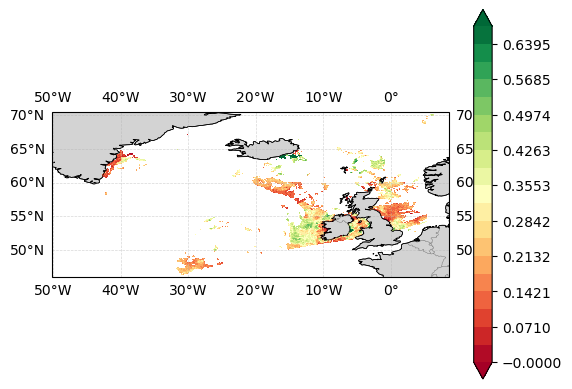

In [30]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = np.min(lon_pace) - buffer_bnd
lon_max = np.max(lon_pace) + buffer_bnd
lat_min = np.min(lat_pace) - buffer_bnd
lat_max = np.max(lat_pace) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extend, crs=ccrs.PlateCarree())  # Global

# Plot nFLH data using contourf
levels = np.linspace(np.nanpercentile(nflh_pace, .5), np.nanpercentile(nflh_pace, 99.5), 20)
im = ax.contourf(lon_pace, lat_pace, nflh_pace, 
                 levels=levels,
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 extend='both')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

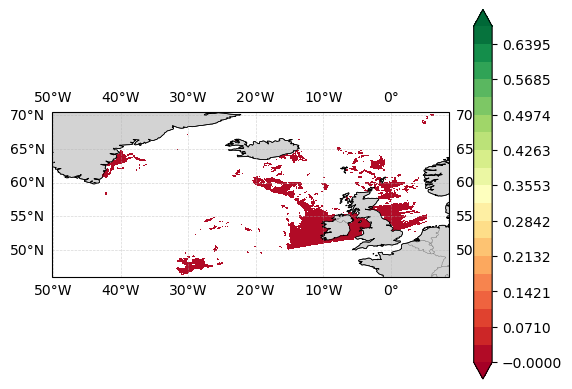

In [35]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = np.min(lon) - buffer_bnd
lon_max = np.max(lon) + buffer_bnd
lat_min = np.min(lat) - buffer_bnd
lat_max = np.max(lat) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extend, crs=ccrs.PlateCarree())  # Global

# Plot nFLH data using contourf
levels = np.linspace(np.nanpercentile(nflh_pace, .5), np.nanpercentile(nflh_pace, 99.5), 20)
im = ax.contourf(lon, lat, x_hat[-5], 
                 levels=levels,
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 extend='both')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')